In [1]:
#importing all the required libraries
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
#importing libraries for metrics
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)


In [3]:
#creating model directory 
os.makedirs("model", exist_ok=True)

In [4]:
#load dataset
df = pd.read_csv("data.csv")

In [5]:
# Drop unnecessary columns
df.drop(columns=["id", "Unnamed: 32"], errors="ignore", inplace=True)

In [6]:
#Enocding Variables
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

In [7]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [8]:
# Imputation
imputer = SimpleImputer(strategy="mean")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

joblib.dump(imputer, "model/imputer.pkl")


['model/imputer.pkl']

In [9]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

joblib.dump(scaler, "model/scaler.pkl")

['model/scaler.pkl']

In [10]:
# Initialize Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "kNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )
}

In [11]:
results = []

for name, model in models.items():

    print("Training:", name)

    # Choose correct data
    if name in ["Decision Tree", "Random Forest"]:
        model.fit(X_train_imp, y_train)
        y_pred = model.predict(X_test_imp)
        y_prob = model.predict_proba(X_test_imp)[:, 1]
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    results.append({
        "ML Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred)
    })

    # Save model
    filename = name.lower().replace(" ", "_") + ".pkl"
    joblib.dump(model, f"model/{filename}")
    print(f"Saved model: {filename}")



Training: Logistic Regression
Saved model: logistic_regression.pkl
Training: Decision Tree
Saved model: decision_tree.pkl
Training: kNN
Saved model: knn.pkl
Training: Naive Bayes
Saved model: naive_bayes.pkl
Training: Random Forest
Saved model: random_forest.pkl
Training: XGBoost
Saved model: xgboost.pkl


In [12]:
# Display Metrics Table
results_df = pd.DataFrame(results)

print("\n-------------MODEL COMPARISON ----------------\n")
print(results_df)


-------------MODEL COMPARISON ----------------

              ML Model  Accuracy       AUC  Precision    Recall  F1 Score  \
0  Logistic Regression  0.964912  0.996032   0.975000  0.928571  0.951220   
1        Decision Tree  0.929825  0.924603   0.904762  0.904762  0.904762   
2                  kNN  0.956140  0.982308   0.974359  0.904762  0.938272   
3          Naive Bayes  0.921053  0.989087   0.923077  0.857143  0.888889   
4        Random Forest  0.973684  0.992890   1.000000  0.928571  0.962963   
5              XGBoost  0.973684  0.994048   1.000000  0.928571  0.962963   

        MCC  
0  0.924518  
1  0.849206  
2  0.905824  
3  0.829162  
4  0.944155  
5  0.944155  


<Figure size 1000x600 with 0 Axes>

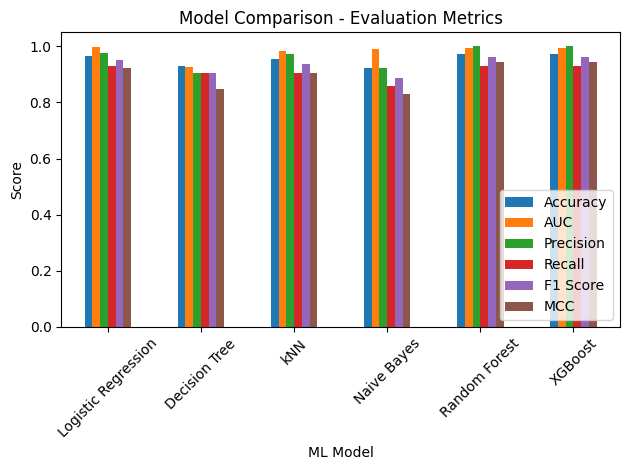

In [13]:
#Bar chart
plot_df = results_df.set_index("ML Model")
# Plot
plt.figure(figsize=(10,6))
plot_df.plot(kind="bar")
plt.title("Model Comparison - Evaluation Metrics")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


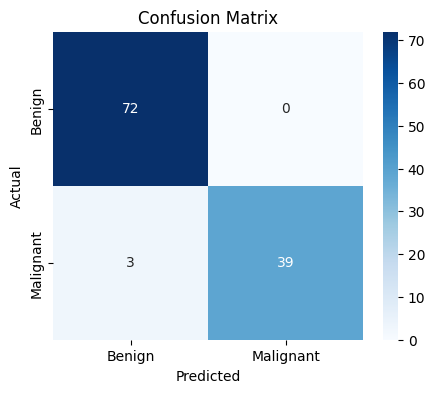

In [14]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [15]:
#Verify saved files

print("\nFiles inside model/ folder:")
print(os.listdir("model"))


Files inside model/ folder:
['imputer.pkl', 'scaler.pkl', 'logistic_regression.pkl', 'decision_tree.pkl', 'knn.pkl', 'naive_bayes.pkl', 'random_forest.pkl', 'xgboost.pkl']
